In [2]:
import sys
import os
sys.path.append(os.path.dirname(os.getcwd()))
from shared.collect_data import DataCollector
from shared.clean_data import DataCleaning
import ta
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import seaborn as sns
import pandas as pd
import numpy as np

# Data Collection

In [7]:
data_collector = DataCollector(
    symbol = "BTC/USDT", 
    timeframe = "1h", 
    days = 1825,
    limit = 1000
)
df = data_collector.collect_data()

In [8]:
df.head()

,timestamp,open,high,low,close,volume
0,2020-10-25 02:00:00,13138.84,13159.35,13117.10,13127.36,880.075473
1,2020-10-25 03:00:00,13127.36,13350.00,13127.35,13295.50,4406.167322
2,2020-10-25 04:00:00,13295.50,13343.20,13215.00,13311.81,2576.622081
3,2020-10-25 05:00:00,13311.80,13311.80,12888.00,12954.56,5623.365987
4,2020-10-25 06:00:00,12954.55,13049.99,12926.98,13013.36,2483.498818


In [9]:
df.tail()

,timestamp,open,high,low,close,volume
43775,2025-10-23 21:00:00,109524.81,109727.22,109380.12,109532.97,424.08473
43776,2025-10-23 22:00:00,109532.96,110158.37,109517.37,109943.94,443.21336
43777,2025-10-23 23:00:00,109943.95,110099.17,109839.00,110078.18,259.37538
43778,2025-10-24 00:00:00,110078.19,110709.22,109983.93,110500.28,531.07612
43779,2025-10-24 01:00:00,110500.29,110665.53,110237.81,110238.93,172.86090


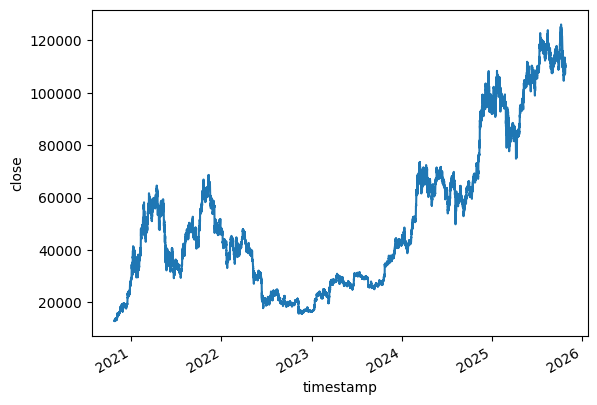

In [10]:
sns.lineplot(x="timestamp", y="close", data=df)
plt.gcf().autofmt_xdate()
plt.show()

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43780 entries, 0 to 43779
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  43780 non-null  datetime64[ns]
 1   open       43780 non-null  float64       
 2   high       43780 non-null  float64       
 3   low        43780 non-null  float64       
 4   close      43780 non-null  float64       
 5   volume     43780 non-null  float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 2.0 MB


In [12]:
df.describe()

,timestamp,open,high,low,close,volume
count,43780,43780.000000,43780.000000,43780.000000,43780.000000,43780.000000
mean,2023-04-25 21:12:14.390132480,51530.826222,51736.592666,51316.720820,51533.044804,3209.055093
min,2020-10-25 02:00:00,12845.310000,12928.370000,12765.000000,12844.520000,0.000000
25%,2022-01-24 21:45:00,27876.385000,27946.200000,27769.675000,27877.550000,803.515292
50%,2023-04-25 23:30:00,43363.070000,43553.965000,43135.385000,43365.525000,1594.568235
75%,2024-07-25 00:15:00,65873.470000,66120.765000,65656.705000,65875.347500,3512.776004
max,2025-10-24 01:00:00,126011.180000,126199.630000,125252.740000,126011.180000,137207.188600
std,NaN,29040.596629,29114.705983,28965.438092,29041.372173,4724.359029


# Technical Indicators

### Momentum

In [13]:
##Awesome Oscillator (AO)
df["AO"] = ta.momentum.AwesomeOscillatorIndicator(
    high=df["high"],
    low=df["low"],
    window1=5,
    window2=34
).awesome_oscillator()

##KAMA
df["KAMA"] = ta.momentum.KAMAIndicator(close=df['close']).kama()

## PPO
ppo = ta.momentum.PercentagePriceOscillator(
    close=df['close'],
    window_slow=26,
    window_fast=12,
    window_sign=9
)

df["PPO"] = ppo.ppo()

df["PPO_HIST"] = ppo.ppo_hist()

df["PPO_SIGNAL"] = ppo.ppo_signal()

## PVO
pvo = ta.momentum.PercentageVolumeOscillator(
    volume =df['volume'],
    window_slow=26,
    window_fast=12,
    window_sign=9
)

df["PVO"] = pvo.pvo()

df["PVO_HIST"] = pvo.pvo_hist()

df["PVO_SIGNAL"] = pvo.pvo_signal()

## ROC
df["ROC"] = ta.momentum.ROCIndicator(
    close=df['close'],
    window=12
).roc()

## RSI
df["RSI"] = ta.momentum.RSIIndicator(close=df['close'], window=14).rsi()

## STOCHASTIC RSI
df["STOCH_RSI"] = ta.momentum.StochRSIIndicator(
    close=df['close'],
    window=14,
    smooth1=3,
    smooth2=3
).stochrsi()

## STOCHASTIC OSCILLATOR
stoch = ta.momentum.StochasticOscillator(
    high=df['high'],
    low=df['low'],
    close=df['close'],
    window=14,
    smooth_window=3
)

df["STOCH_OSC"] = stoch.stoch()

df["STOCH_OSC_SIGNAL"] = stoch.stoch_signal()

## TSI
df["TSI"] = ta.momentum.TSIIndicator(
    close=df['close'],
    window_slow=25,
    window_fast=13
).tsi()

### Volume

In [14]:
## ADI
adi = ta.volume.AccDistIndexIndicator(
    high=df['high'],
    low=df['low'],
    close=df['close'],
    volume=df['volume']
)

df["ADI"] = adi.acc_dist_index()

## CMF
cmf = ta.volume.ChaikinMoneyFlowIndicator(
    high=df['high'],
    low=df['low'],
    close=df['close'],
    volume=df['volume'],
    window=20
)

df["CMF"] = cmf.chaikin_money_flow()

##EoM EMV
emi = ta.volume.EaseOfMovementIndicator(
    high=df["high"], low=df["low"], volume=df["volume"], window=14
)

df["EoM"] = emi.ease_of_movement()
df["EMV"] = emi.sma_ease_of_movement()

##FI
fi = ta.volume.ForceIndexIndicator(
    close=df["close"], volume=df["volume"], window=13
)

df["FI"] = fi.force_index()

##MFI
mfi = ta.volume.MFIIndicator(
    high=df["high"], low=df["low"], close=df["close"], volume=df["volume"], window=14
)

df["MFI"] = mfi.money_flow_index()

##NVI
nvi = ta.volume.NegativeVolumeIndexIndicator(
    close=df["close"], volume=df["volume"]
)

df["NVI"] = nvi.negative_volume_index()

##OBV
obv = ta.volume.OnBalanceVolumeIndicator(
    close=df["close"], volume=df["volume"]
)

df["OBV"] = obv.on_balance_volume()

##VPT
vpt = ta.volume.VolumePriceTrendIndicator(
    close=df["close"], volume=df["volume"]
)

df["VPT"] = vpt.volume_price_trend()

## VWAP
vwap = ta.volume.VolumeWeightedAveragePrice(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    volume=df["volume"],
    window=14
)

df["VWAP"] = vwap.volume_weighted_average_price()

### Volatility

In [15]:
## ATR
atr = ta.volatility.AverageTrueRange(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=14,
)

df["ATR"] = atr.average_true_range()

## BBANDS
bbands = ta.volatility.BollingerBands(
    close=df["close"],
    window=20,
    window_dev=2
)

df["BBANDS_HIGH"] = bbands.bollinger_hband()
df["BBANDS_HIGH_INDI"] = bbands.bollinger_hband_indicator()
df["BBANDS_LOWER"] = bbands.bollinger_lband()
df["BBANDS_LOWER_INDI"] = bbands.bollinger_lband_indicator()
df["BBANDS_MIDDLE"] = bbands.bollinger_mavg()
df["BBANDS_CHANNEL"] = bbands.bollinger_pband()
df["BBANDS_WIDTH"] = bbands.bollinger_wband()

## DONCHIAN CHANNEL
donchian = ta.volatility.DonchianChannel(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=20
)

df["DONCHIAN_HIGH"] = donchian.donchian_channel_hband()
df["DONCHIAN_LOW"] = donchian.donchian_channel_lband()
df["DONCHIAN_MIDDLE"] = donchian.donchian_channel_mband()
df["DONCHIAN_PERCENTAGE"] = donchian.donchian_channel_pband()
df["DONCHIAN_WIDTH"] = donchian.donchian_channel_wband()

## KELTNER CHANNEL
keltner = ta.volatility.KeltnerChannel(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=20,
    window_atr=10,
)

df["KELTNER_HIGH"] = keltner.keltner_channel_hband()
df["KELTNER_HIGH_INDI"] = keltner.keltner_channel_hband_indicator()
df["KELTNER_LOW"] = keltner.keltner_channel_lband()
df["KELTNER_LOW_INDI"] = keltner.keltner_channel_lband_indicator()
df["KELTNER_MIDDLE"] = keltner.keltner_channel_mband()
df["KELTNER_PERCENTAGE"] = keltner.keltner_channel_pband()
df["KELTNER_WIDTH"] = keltner.keltner_channel_wband()

## Ulcer Index
ui = ta.volatility.UlcerIndex(
    close=df["close"],
    window=14
)

df["ULCER_INDEX"] = ui.ulcer_index()

### Trend

In [16]:
## ADX
adx = ta.trend.ADXIndicator(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=14,
)

df["ADX"] = adx.adx()
df["ADX_POS"] = adx.adx_pos()
df["ADX_NEG"] = adx.adx_neg()

## AROON
aroon = ta.trend.AroonIndicator(
    high=df["high"],
    low=df["low"],
    window=25
)

df["AROON_UP"] = aroon.aroon_up()
df["AROON_DOWN"] = aroon.aroon_down()
df["AROON_INDI"] = aroon.aroon_indicator()

## CCI
cci = ta.trend.CCIIndicator(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=20
)

df["CCI"] = cci.cci()

## DPO
dpo = ta.trend.DPOIndicator(
    close=df["close"],
    window=20
)

df["DPO"] = dpo.dpo()

## EMA
ema = ta.trend.EMAIndicator(
    close=df["close"],
    window=14
)

df["EMA"] = ema.ema_indicator()

## KST
kst = ta.trend.KSTIndicator(
    close=df["close"],
    roc1=10,
    roc2=15,
    roc3=20,
    roc4=30,
    window1=10,
    window2=10,
    window3=10,
    window4=15,
    nsig =9
)

df["KST"] = kst.kst()
df["KST_SIGNAL"] = kst.kst_sig()
df["KST_DIFF"] = kst.kst_diff()

## MACD
macd = ta.trend.MACD(
    close=df["close"],
    window_slow=26,
    window_fast=12,
    window_sign=9
)

df["MACD"] = macd.macd()
df["MACD_SIGNAL"] = macd.macd_signal()
df["MACD_DIFF"] = macd.macd_diff()

## MI
mi = ta.trend.MassIndex(
    high=df["high"],
    low=df["low"],
    window_slow=25,
    window_fast=9
)

df["MASS_INDEX"] = mi.mass_index()

## SMA
sma = ta.trend.SMAIndicator(
    close=df["close"],
    window=14
)

df["SMA"] = sma.sma_indicator()

## VI
vi = ta.trend.VortexIndicator(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=14
)

df["VI_POS"] = vi.vortex_indicator_pos()
df["VI_NEG"] = vi.vortex_indicator_neg()
df["VI_DIFF"] = vi.vortex_indicator_diff()

## WMA
wma = ta.trend.WMAIndicator(
    close=df["close"],
    window=14
)

df["WMA"] = wma.wma()

# Data Cleaning

In [17]:
dataset = df.copy()
data_cleaning = DataCleaning()
dataset = data_cleaning.dropna(dataset)
dataset = data_cleaning.drop_duplicates(dataset)

In [18]:
dataset.head()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,KST_DIFF,MACD,MACD_SIGNAL,MACD_DIFF,MASS_INDEX,SMA,VI_POS,VI_NEG,VI_DIFF,WMA
40,2020-10-26 18:00:00,12875.03,12977.60,12855.00,12963.25,2865.242887,-51.258176,13040.703010,-0.183889,-0.176807,...,77.065662,-23.984911,-0.904408,-23.080503,26.285025,13056.022857,0.883722,1.098861,-0.215139,13029.172667
41,2020-10-26 19:00:00,12963.24,13008.17,12920.70,13004.50,2206.790136,-93.566029,13039.986223,-0.179288,-0.137766,...,76.690891,-23.379758,-5.399478,-17.980280,26.451943,13048.956429,0.899559,1.085611,-0.186052,13022.302952
42,2020-10-26 20:00:00,13004.49,13055.60,12987.00,12996.08,1840.607220,-97.857647,13038.701281,-0.178805,-0.109826,...,76.368599,-23.310880,-8.981758,-14.329121,26.519645,13043.100714,0.959204,1.033597,-0.074393,13015.252762
43,2020-10-26 21:00:00,12996.09,13046.72,12996.07,13013.72,1054.888283,-78.316265,13037.775372,-0.165582,-0.077282,...,76.078076,-21.584085,-11.502224,-10.081861,26.566823,13041.432143,0.991584,1.027358,-0.035774,13011.335333
44,2020-10-26 22:00:00,13013.72,13043.21,12983.26,13043.21,994.235217,-46.510088,13037.904470,-0.135263,-0.037571,...,76.260372,-17.632732,-12.728325,-4.904406,26.592618,13040.634286,1.034162,1.027446,0.006716,13011.572381


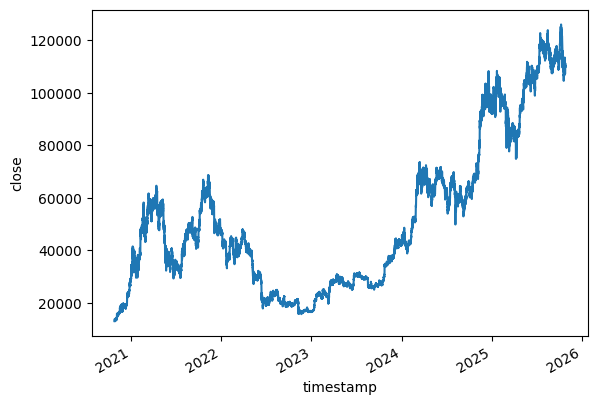

In [19]:
sns.lineplot(x="timestamp", y="close", data=dataset)
plt.gcf().autofmt_xdate()
plt.show()

In [20]:
dataset.head()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,KST_DIFF,MACD,MACD_SIGNAL,MACD_DIFF,MASS_INDEX,SMA,VI_POS,VI_NEG,VI_DIFF,WMA
40,2020-10-26 18:00:00,12875.03,12977.60,12855.00,12963.25,2865.242887,-51.258176,13040.703010,-0.183889,-0.176807,...,77.065662,-23.984911,-0.904408,-23.080503,26.285025,13056.022857,0.883722,1.098861,-0.215139,13029.172667
41,2020-10-26 19:00:00,12963.24,13008.17,12920.70,13004.50,2206.790136,-93.566029,13039.986223,-0.179288,-0.137766,...,76.690891,-23.379758,-5.399478,-17.980280,26.451943,13048.956429,0.899559,1.085611,-0.186052,13022.302952
42,2020-10-26 20:00:00,13004.49,13055.60,12987.00,12996.08,1840.607220,-97.857647,13038.701281,-0.178805,-0.109826,...,76.368599,-23.310880,-8.981758,-14.329121,26.519645,13043.100714,0.959204,1.033597,-0.074393,13015.252762
43,2020-10-26 21:00:00,12996.09,13046.72,12996.07,13013.72,1054.888283,-78.316265,13037.775372,-0.165582,-0.077282,...,76.078076,-21.584085,-11.502224,-10.081861,26.566823,13041.432143,0.991584,1.027358,-0.035774,13011.335333
44,2020-10-26 22:00:00,13013.72,13043.21,12983.26,13043.21,994.235217,-46.510088,13037.904470,-0.135263,-0.037571,...,76.260372,-17.632732,-12.728325,-4.904406,26.592618,13040.634286,1.034162,1.027446,0.006716,13011.572381


# Feature Engineering

### Timestamp Features

In [23]:
dataset["hour"] = dataset['timestamp'].dt.hour
dataset['dayofweek'] = dataset['timestamp'].dt.dayofweek
dataset['quarter'] = dataset['timestamp'].dt.quarter
dataset['month'] = dataset['timestamp'].dt.month
dataset['year'] = dataset['timestamp'].dt.year
dataset['dayofyear'] = dataset['timestamp'].dt.dayofyear
dataset['dayofmonth'] = dataset['timestamp'].dt.day

In [24]:
dataset.tail()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,VI_NEG,VI_DIFF,WMA,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth
43775,2025-10-23 21:00:00,109524.81,109727.22,109380.12,109532.97,424.08473,1347.656971,109773.765429,0.352696,-0.000678,...,1.052228,-0.035748,109940.139714,21,3,4,10,2025,296,23
43776,2025-10-23 22:00:00,109532.96,110158.37,109517.37,109943.94,443.21336,1164.491588,109779.028457,0.337027,-0.013077,...,0.975623,0.050416,109960.006476,22,3,4,10,2025,296,23
43777,2025-10-23 23:00:00,109943.95,110099.17,109839.00,110078.18,259.37538,954.791647,109785.868796,0.330653,-0.015561,...,0.946162,0.123493,109993.595714,23,3,4,10,2025,296,23
43778,2025-10-24 00:00:00,110078.19,110709.22,109983.93,110500.28,531.07612,889.823265,109811.701474,0.352515,0.005041,...,0.905616,0.151903,110077.263143,0,4,4,10,2025,297,24
43779,2025-10-24 01:00:00,110500.29,110665.53,110237.81,110238.93,172.86090,967.169147,109816.961325,0.346619,-0.000684,...,0.904253,0.203612,110115.978381,1,4,4,10,2025,297,24


In [25]:
dataset = data_cleaning.dropna(dataset)
dataset = data_cleaning.drop_duplicates(dataset)

# Feature Selection

In [26]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, TimeSeriesSplit
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

In [27]:
dataset = dataset.sort_values('timestamp')

In [28]:
X_close = dataset.drop(['timestamp', 'close'], axis=1)
y_close = dataset['close']

### Feature Importance

In [29]:
xgb_close = XGBRegressor(
    device='cuda',
    max_bin=256,
    eval_metric='rmse',
)

In [30]:
tscv = TimeSeriesSplit(n_splits=100)

##### Train the model

In [32]:
## Train the model
def model_training(X, y, model, tscv):
    fold_metrics = []
    n = len(X)
    oof_pred = np.full(shape=n, fill_value=np.nan, dtype=float)
    feature_names = X.columns.tolist()
    fold_id = 0
    gain_accum = pd.Series(0.0, index=feature_names)

    for train_idx, val_idx in tscv.split(X):
        fold_id += 1
        X_train, X_test = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(
            X_train, y_train,
            eval_set=[(X_test, y_test)],
            verbose=False,
        )

        # OOF predictions for this fold’s validation window
        y_val_pred = model.predict(X_test)
        oof_pred[val_idx] = y_val_pred

        # Fold metrics
        rmse = root_mean_squared_error(y_test, y_val_pred)
        mae  = mean_absolute_error(y_test, y_val_pred)
        fold_metrics.append({"fold": fold_id, "rmse": rmse, "mae": mae})

        # Gain importances for this fold (reindexed to all features, missing -> 0)
        gain_dict = model.get_booster().get_score(importance_type="gain")
        gain_fold = pd.Series(gain_dict, dtype=float)

        # xgboost keys are the raw feature names; ensure alignment
        gain_fold.index = [k for k in gain_fold.index]  # no-op but explicit
        gain_fold = gain_fold.reindex(feature_names).fillna(0.0)
        gain_accum += gain_fold

    return fold_metrics, oof_pred, gain_accum


### Get most value variables

In [34]:
features_by_target = {}
fold_metrics, oof_pred, gain_accum = model_training(X_close, y_close, xgb_close, tscv)
importance_df = (
    gain_accum.div(100)             # average gain across folds
    .sort_values(ascending=False)
    .rename("avg_gain")
    .reset_index()
    .rename(columns={"index": "feature"})
)
importance_df["gain_pct"] = (importance_df["avg_gain"] / importance_df["avg_gain"].sum()) * 100
features_by_target["close"] = importance_df[importance_df["gain_pct"] > 0.5]["feature"].tolist()

c:\Users\DG\Desktop\trading-bot-project\data_analysis_trading_bot\venv\Lib\site-packages\xgboost\core.py:729: UserWarning: [19:54:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


In [35]:
features_by_target

{'close': ['high',
  'low',
  'DONCHIAN_MIDDLE',
  'KAMA',
  'DONCHIAN_HIGH',
  'EMA',
  'DONCHIAN_LOW',
  'VWAP',
  'SMA',
  'BBANDS_LOWER',
  'BBANDS_HIGH',
  'open',
  'ADI',
  'WMA']}

In [50]:
all_features = features_by_target["close"] + ["close"]

### Save Selected Features

In [37]:
import os
import json
from datetime import datetime
model_folder = "saved_models"
os.makedirs(model_folder, exist_ok=True)

In [38]:
with open('feature_selection/features_by_target_1h_lstm.json', 'w') as f:
    json.dump(features_by_target, f, indent=4)

# Split train, val, test data

In [44]:
train_size = int(len(dataset) * 0.8)
val_size = int(len(dataset) * 0.10)

In [45]:
train_df = dataset[:train_size].copy()
val_df = dataset[train_size:train_size+val_size].copy()
test_df = dataset[train_size+val_size:].copy()

In [47]:
train_df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,VI_NEG,VI_DIFF,WMA,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth
count,34969,34969.000000,34969.000000,34969.000000,34969.000000,34969.000000,34969.000000,34969.000000,34969.000000,34969.000000,...,34969.000000,34969.000000,34969.000000,34969.000000,34969.000000,34969.000000,34969.000000,34969.000000,34969.000000,34969.000000
mean,2022-10-26 17:41:38.555863808,39291.342942,39470.012999,39103.084503,39292.849164,3758.627784,22.483268,39291.483431,0.027842,-0.000040,...,0.991839,0.018473,39286.324322,11.502045,2.997055,2.507621,6.520947,2022.318511,183.046899,15.712717
min,2020-10-26 18:00:00,12875.030000,12977.600000,12855.000000,12963.250000,5.887034,-6922.829941,13037.775372,-4.715038,-1.360963,...,0.355984,-1.097732,13011.335333,0.000000,0.000000,1.000000,1.000000,2020.000000,1.000000,1.000000
25%,2021-10-27 09:00:00,26087.160000,26149.430000,26040.170000,26088.010000,1046.125280,-271.034912,26090.167561,-0.300993,-0.107293,...,0.893316,-0.185303,26081.389333,6.000000,1.000000,2.000000,4.000000,2021.000000,92.000000,8.000000
50%,2022-10-26 15:00:00,37455.330000,37720.390000,37250.550000,37455.320000,1989.474590,13.678559,37442.718130,0.022838,-0.003662,...,1.000693,0.010286,37430.210857,12.000000,3.000000,3.000000,7.000000,2022.000000,183.000000,16.000000
75%,2023-10-26 12:00:00,52398.990000,52774.710000,52103.210000,52407.190000,4296.272331,332.561676,52264.584095,0.379470,0.101887,...,1.096580,0.217214,52265.806095,18.000000,5.000000,4.000000,10.000000,2023.000000,274.000000,23.000000
max,2024-10-24 18:00:00,73577.350000,73777.000000,73215.140000,73577.350000,137207.188600,4885.644059,73032.432170,4.293264,1.461292,...,1.576494,1.144899,73196.516190,23.000000,6.000000,4.000000,12.000000,2024.000000,366.000000,31.000000
std,NaN,16074.665888,16142.364037,16001.599234,16074.725076,5108.168208,802.507182,16068.067995,0.762639,0.226334,...,0.155437,0.305785,16069.828515,6.922790,1.999733,1.116168,3.448061,1.181998,105.404618,8.800962


In [48]:
val_df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,VI_NEG,VI_DIFF,WMA,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth
count,4371,4371.000000,4371.000000,4371.000000,4371.000000,4371.000000,4371.000000,4371.000000,4371.000000,4371.000000,...,4371.000000,4371.000000,4371.000000,4371.000000,4371.000000,4371.000000,4371.000000,4371.000000,4371.000000,4371.000000
mean,2025-01-23 20:00:00,90938.552736,91296.686484,90581.273121,90944.393526,1319.193476,85.690748,90947.631313,0.048863,-0.000155,...,0.988928,0.024180,90918.962141,11.505834,3.000000,2.254862,5.763898,2024.625486,160.425989,15.692519
min,2024-10-24 19:00:00,66626.430000,66800.000000,65596.290000,66626.420000,92.538770,-6140.157853,67114.120799,-2.191137,-1.052384,...,0.497574,-0.932262,66880.162667,0.000000,0.000000,1.000000,1.000000,2024.000000,1.000000,1.000000
25%,2024-12-09 07:30:00,84257.490000,84492.415000,84021.820000,84258.510000,522.837525,-670.735515,84332.056098,-0.280210,-0.100624,...,0.877575,-0.203495,84259.968571,6.000000,1.000000,1.000000,2.000000,2024.000000,46.000000,8.000000
50%,2025-01-23 20:00:00,93918.990000,94316.090000,93500.000000,93918.990000,868.210530,95.540441,94298.326530,0.057275,-0.005403,...,0.997239,0.019493,93913.950190,12.000000,3.000000,2.000000,4.000000,2025.000000,92.000000,16.000000
75%,2025-03-10 08:30:00,97691.155000,98007.915000,97397.135000,97691.155000,1575.033160,834.970882,97701.570833,0.384929,0.090564,...,1.105783,0.245661,97620.207524,18.000000,5.000000,4.000000,11.000000,2025.000000,321.000000,23.000000
max,2025-04-24 21:00:00,108320.000000,109588.000000,107780.510000,108320.010000,15098.554220,6547.834647,106941.139894,2.673969,0.980659,...,1.455401,0.919626,107196.930762,23.000000,6.000000,4.000000,12.000000,2025.000000,366.000000,31.000000
std,NaN,9480.869825,9505.189439,9448.550218,9474.498125,1381.726003,1429.111240,9466.251114,0.615420,0.197623,...,0.161073,0.321482,9474.655940,6.924215,1.999542,1.388419,4.427198,0.484053,136.135855,8.786024


In [49]:
test_df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,VI_NEG,VI_DIFF,WMA,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth
count,4372,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,...,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.0,4372.000000,4372.000000
mean,2025-07-24 23:30:00,110474.542710,110745.593449,110195.274831,110478.406132,706.051142,54.829911,110438.889415,0.024707,0.000232,...,0.987908,0.026088,110461.710162,11.500000,3.000457,2.758463,7.274474,2025.0,205.500000,15.716377
min,2025-04-24 22:00:00,92950.000000,93387.090000,92800.010000,92949.990000,55.663110,-7454.810529,93131.090738,-2.075407,-0.657540,...,0.432131,-0.927851,93244.864381,0.000000,0.000000,2.000000,4.000000,2025.0,114.000000,1.000000
25%,2025-06-09 10:45:00,105805.182500,106090.077500,105538.017500,105814.245000,324.983463,-484.543765,105791.234309,-0.180257,-0.068083,...,0.877485,-0.202251,105752.800190,5.000000,1.000000,2.000000,6.000000,2025.0,160.000000,8.000000
50%,2025-07-24 23:30:00,110647.960000,110919.930000,110311.870000,110647.955000,512.223080,62.940691,110530.308710,0.025314,0.001087,...,0.990823,0.030740,110607.974762,11.500000,3.000000,3.000000,7.000000,2025.0,205.500000,16.000000
75%,2025-09-08 12:15:00,115936.985000,116110.777500,115712.797500,115936.985000,834.987820,674.357721,115819.450388,0.255137,0.071227,...,1.103446,0.248173,115875.548595,18.000000,5.000000,3.000000,9.000000,2025.0,251.000000,23.000000
max,2025-10-24 01:00:00,126011.180000,126199.630000,125252.740000,126011.180000,22932.630340,4377.418029,124738.383319,1.514353,0.471414,...,1.446579,1.044153,125145.716667,23.000000,6.000000,4.000000,10.000000,2025.0,297.000000,31.000000
std,NaN,6912.308263,6918.538137,6898.946034,6907.456166,738.834588,1118.747342,6884.773553,0.396028,0.119690,...,0.162199,0.320758,6906.771100,6.927823,1.999428,0.660854,1.743743,0.0,52.592938,8.810368


# Scale the data

In [39]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
scaler = MinMaxScaler()

In [52]:
train_scaled = scaler.fit_transform(train_df[all_features])
val_scaled = scaler.transform(val_df[all_features])
test_scaled = scaler.transform(test_df[all_features])

print(f"\nScaled data shape: {train_scaled.shape}")


Scaled data shape: (34969, 15)


# Create sequences - multi step output

In [77]:
def create_sequences_multistep(data, lookback=168, forecast_horizon=24):
    """
    Create sequences for multi-step forecasting.
    
    lookback: hours to look back (e.g., 168 = 1 week)
    forecast_horizon: hours to predict ahead (e.g., 24 = 1 day)
    """
    X, y = [], []
    
    for i in range(len(data) - lookback - forecast_horizon + 1):
        # Input: lookback hours of all features
        X.append(data[i:i+lookback, :-1])  # All features except target
        
        # Output: next forecast_horizon hours of target only
        y.append(data[i+lookback:i+lookback+forecast_horizon, -1])
    
    return np.array(X), np.array(y)

In [61]:
lookback = 168  # Use last week (168 hours) to predict
forecast_horizon = 24  # Predict next 24 hours

In [78]:
X_train, y_train = create_sequences_multistep(train_scaled, lookback, forecast_horizon)
X_val, y_val = create_sequences_multistep(val_scaled, lookback, forecast_horizon)
X_test, y_test = create_sequences_multistep(test_scaled, lookback, forecast_horizon)

In [67]:
print(f"\n=== Sequence Shapes ===")
print(f"X_train: {X_train.shape} -> (samples, {lookback} hours, {X_train.shape[2]} features)")
print(f"y_train: {y_train.shape} -> (samples, {forecast_horizon} hours to predict)")


=== Sequence Shapes ===
X_train: (34778, 168, 14) -> (samples, 168 hours, 14 features)
y_train: (34778, 24) -> (samples, 24 hours to predict)


# Hyperparameter Tuning

# Build multi output LSTM model

In [84]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, RepeatVector, TimeDistributed
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input

In [85]:
def build_multistep_lstm(input_shape, forecast_horizon, units=128):
    model = Sequential([
        Input(shape=input_shape),  # Add this!
        
        # Encoder
        LSTM(units, return_sequences=True),  # Remove input_shape parameter
        Dropout(0.2),
        LSTM(units),
        Dropout(0.2),
        
        # Output
        Dense(units),
        Dropout(0.2),
        Dense(forecast_horizon)
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    return model

In [86]:
model = build_multistep_lstm(
    input_shape=(X_train.shape[1], X_train.shape[2]),
    forecast_horizon=forecast_horizon,
    units=128
)

print("\n=== Model Architecture ===")
model.summary()


=== Model Architecture ===


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 168, 128)       │        73,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 168, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 224,408 (876.59 KB)

 Trainable params: 224,408 (876.59 KB)

 Non-trainable params: 0 (0.00 B)

# Train LSTM model

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [88]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]

print("\n=== Training Model ===")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)


=== Training Model ===
Epoch 1/100
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 118s 106ms/step - loss: 0.0044 - mae: 0.0418 - val_loss: 0.0101 - val_mae: 0.0923 - learning_rate: 0.0010
Epoch 2/100
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 116s 107ms/step - loss: 0.0014 - mae: 0.0274 - val_loss: 0.0111 - val_mae: 0.0965 - learning_rate: 0.0010
Epoch 3/100
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 116s 107ms/step - loss: 0.0011 - mae: 0.0247 - val_loss: 0.0055 - val_mae: 0.0635 - learning_rate: 0.0010
Epoch 4/100
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 141s 106ms/step - loss: 0.0010 - mae: 0.0236 - val_loss: 0.0126 - val_mae: 0.1009 - learning_rate: 0.0010
Epoch 5/100
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 142s 106ms/step - loss: 9.2156e-04 - mae: 0.0223 - val_loss: 0.0182 - val_mae: 0.1238 - learning_rate: 0.0010
Epoch 6/100
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 117s 108ms/step - loss: 8.6086e-04 - mae: 0.0215 - val_loss: 0.0267 - val_mae: 0.1505 - learning_rate: 0.0010
Epoch 7/100
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 115s 106ms/step - loss: 8.1050e

# Make Predictions

In [89]:
y_test_pred = model.predict(X_test)

print(f"\nPrediction shape: {y_test_pred.shape} -> (samples, 24 hours)")

131/131 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step

Prediction shape: (4181, 24) -> (samples, 24 hours)


# Inverse Transform

In [90]:
def inverse_transform_target(values, scaler, n_features):
    """Inverse transform target values back to original scale."""
    dummy = np.zeros((len(values), n_features))
    dummy[:, -1] = values
    inversed = scaler.inverse_transform(dummy)
    return inversed[:, -1]

In [91]:
# Inverse transform predictions (all 24 hours for all samples)
n_features = len(all_features)
y_test_pred_original = np.zeros_like(y_test_pred)
y_test_actual_original = np.zeros_like(y_test)

for i in range(y_test_pred.shape[0]):
    y_test_pred_original[i] = inverse_transform_target(
        y_test_pred[i], scaler, n_features
    )
    y_test_actual_original[i] = inverse_transform_target(
        y_test[i], scaler, n_features
    )

# Evaluate Model

In [92]:
from sklearn.metrics import mean_squared_error, mean_absolute_error


In [95]:
# Overall metrics
rmse_overall = np.sqrt(mean_squared_error(
    y_test_actual_original.flatten(), 
    y_test_pred_original.flatten()
))
mae_overall = mean_absolute_error(
    y_test_actual_original.flatten(), 
    y_test_pred_original.flatten()
)

print(f"\n=== Overall Test Metrics ===")
print(f"RMSE: {rmse_overall:.4f}")
print(f"MAE: {mae_overall:.4f}")

# Per-horizon metrics (how good is each hour prediction?)
print(f"\n=== Metrics by Forecast Horizon ===")
for h in range(0, forecast_horizon, 1):  # Every 6 hours
    rmse_h = np.sqrt(mean_squared_error(
        y_test_actual_original[:, h],
        y_test_pred_original[:, h]
    ))
    mae_h = mean_absolute_error(
        y_test_actual_original[:, h],
        y_test_pred_original[:, h]
    )
    print(f"Hour +{h+1:2d}: RMSE={rmse_h:.4f}, MAE={mae_h:.4f}")


=== Overall Test Metrics ===
RMSE: 10203.1658
MAE: 9824.4851

=== Metrics by Forecast Horizon ===
Hour + 1: RMSE=10316.5063, MAE=9994.2567
Hour + 2: RMSE=10074.4506, MAE=9743.0282
Hour + 3: RMSE=9450.8370, MAE=9108.3716
Hour + 4: RMSE=9982.4419, MAE=9648.0357
Hour + 5: RMSE=10169.5221, MAE=9823.1236
Hour + 6: RMSE=10473.5242, MAE=10112.3060
Hour + 7: RMSE=9972.2587, MAE=9614.5379
Hour + 8: RMSE=10177.6885, MAE=9833.3326
Hour + 9: RMSE=10429.8799, MAE=10074.9681
Hour +10: RMSE=9388.4530, MAE=8995.7029
Hour +11: RMSE=10229.0661, MAE=9866.6419
Hour +12: RMSE=10341.9402, MAE=9979.0143
Hour +13: RMSE=10638.3946, MAE=10268.3096
Hour +14: RMSE=10176.5924, MAE=9801.6899
Hour +15: RMSE=10217.6066, MAE=9833.7948
Hour +16: RMSE=10383.7932, MAE=9997.9654
Hour +17: RMSE=10697.3572, MAE=10318.9318
Hour +18: RMSE=10229.4689, MAE=9814.2152
Hour +19: RMSE=10562.8651, MAE=10176.9913
Hour +20: RMSE=10351.4341, MAE=9955.0650
Hour +21: RMSE=10350.4196, MAE=9947.2181
Hour +22: RMSE=9950.4983, MAE=9540.3351

# Visualize predictions

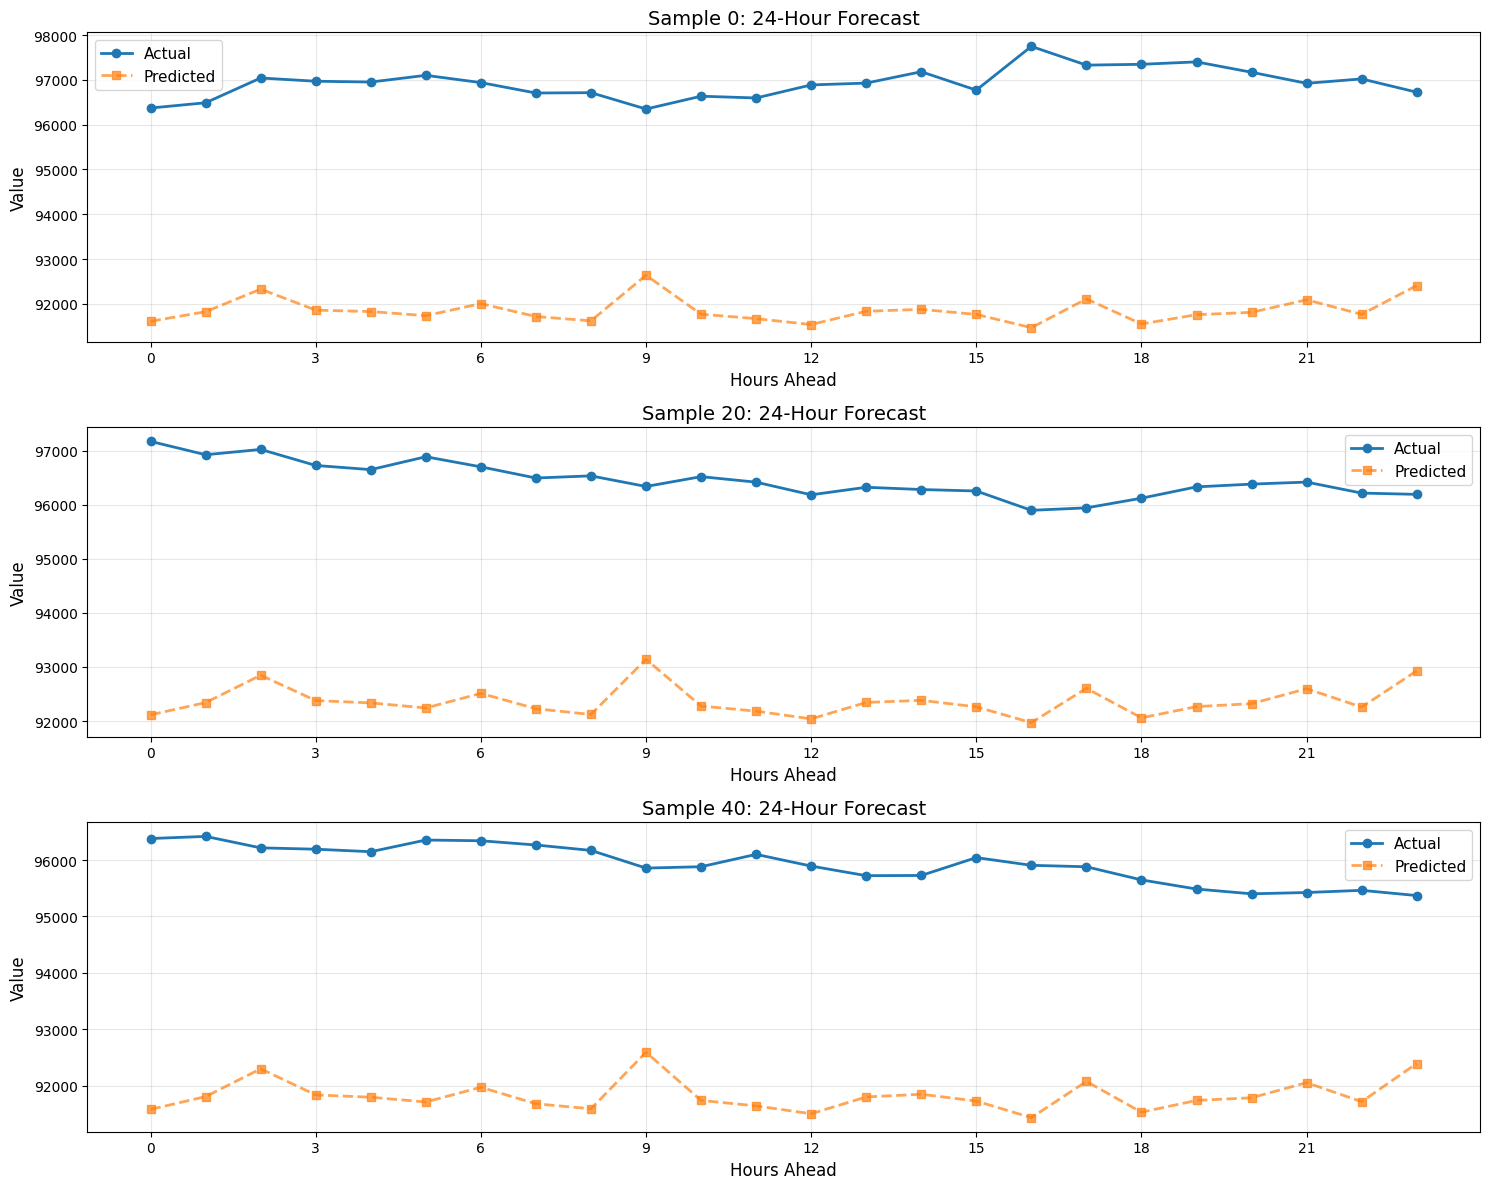

In [94]:
# Plot a few example predictions
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

for idx, ax in enumerate(axes):
    sample_idx = idx * 20  # Show predictions at different points
    
    ax.plot(range(24), y_test_actual_original[sample_idx], 
            'o-', label='Actual', linewidth=2, markersize=6)
    ax.plot(range(24), y_test_pred_original[sample_idx], 
            's--', label='Predicted', linewidth=2, markersize=6, alpha=0.7)
    
    ax.set_xlabel('Hours Ahead', fontsize=12)
    ax.set_ylabel('Value', fontsize=12)
    ax.set_title(f'Sample {sample_idx}: 24-Hour Forecast', fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(0, 24, 3))

plt.tight_layout()
plt.show()